---
# RL Basics 1: Dynamic Programming
---

Before an agent can *learn* from experience, it helps to know what it is trying to learn.

In this notebook the environment's dynamics are **fully known**: we have the transition probabilities $p(s' \mid s, a)$ and the rewards $r(s, a)$ written down. That turns reinforcement learning into a **planning** problem, which we can solve **exactly** — with linear algebra, no sampling, no learning rates, no exploration.

This matters for what comes next. In `RL02` you will estimate value functions from sampled trajectories using Monte Carlo and Temporal Difference methods. Those methods are approximations *of the quantities computed here*. Having the exact answer in hand means you can measure how wrong an estimate is, rather than eyeballing whether it looks reasonable.

We will cover:

1. **The MDP as matrices** — turning `env.P` into $P$ and $R$
2. **Exact policy evaluation** — solving a linear system for $V^\pi$
3. **Iterative policy evaluation** — the same answer as a fixed point
4. **Policy iteration** — evaluate, improve, repeat
5. **Value iteration** — collapsing the two steps into one

In this notebook you will find some **⭐ Exercise**s where you need to implement missing parts in the code. When you need to complete some code, the section is marked as:
```python
# Your code goes here: -------------------------------------

# ----------------------------------------------------------
```

# ⚙️ Setup

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

from rl_basics.utils import *
setup()

seed_everything(0)

We use the same **cliff walking** environment as `RL00`: a $4 \times 12$ grid whose bottom-right cell is the goal, with a cliff running along the rest of the bottom row. Every step costs $-1$; falling off the cliff costs $-100$ and ends the episode.

_Remark._ `reset` places the agent uniformly at random on any non-cliff cell, not always at the bottom-left. Dynamic programming computes $V(s)$ for **every** state at once, so this makes no difference to what follows — we simply report the bottom-left cell as a convenient reference point.

In [2]:
env = gym.make("CliffWalking-RLSS-v0").unwrapped

nS, nA = env.nS, env.nA
shape  = env.shape
START  = np.ravel_multi_index((3, 0), shape)
GOAL   = np.ravel_multi_index((3, 11), shape)

print(f"{nS} states, {nA} actions  |  grid {shape}  |  start={START}, goal={GOAL}")

48 states, 4 actions  |  grid (4, 12)  |  start=36, goal=47


---
# 🧱 The MDP as Matrices

A finite MDP is the tuple $(\mathcal{S}, \mathcal{A}, p, r, \gamma)$. Gymnasium's toy-text environments expose the dynamics through the attribute `env.P`, a nested dictionary:

```
env.P[s][a] -> [(probability, next_state, reward, terminated), ...]
```

Each entry is one possible outcome of taking action $a$ in state $s$. Let's look at one state.

In [3]:
s = np.ravel_multi_index((2, 1), shape)   # directly above the cliff
for a, name in enumerate(["UP", "RIGHT", "DOWN", "LEFT"]):
    print(f"{name:6} -> {env.P[s][a]}")

UP     -> [(1.0, np.int64(13), -1, False)]
RIGHT  -> [(1.0, np.int64(26), -1, False)]
DOWN   -> [(1.0, np.int64(36), -100, False)]
LEFT   -> [(1.0, np.int64(24), -1, False)]


Every action here is deterministic: one outcome with probability $1.0$.

Notice the `DOWN` action. It steps into the cliff, and the environment reports reward $-100$ with the next state set back to the start — the fall is encoded as a teleport rather than as a terminal transition.

### Terminal transitions and the absorbing state

There is a subtlety worth being explicit about. Once an episode **terminates**, no further reward is collected. If we naively wrote $V(s) = r + \gamma V(s')$ for a terminating transition, we would incorrectly keep accumulating value from $s'$.

The standard fix is an **absorbing state**: a single extra state $\bot$ that all terminating transitions lead into, which loops to itself forever with reward $0$. Then $V(\bot) = 0$ automatically, and the Bellman equation needs no special-casing for terminal states.

We will build:

- $P \in \mathbb{R}^{(|\mathcal{S}|+1) \times |\mathcal{A}| \times (|\mathcal{S}|+1)}$ with $P[s, a, s'] = p(s' \mid s, a)$
- $R \in \mathbb{R}^{(|\mathcal{S}|+1) \times |\mathcal{A}|}$ with $R[s, a] = \mathbb{E}[r \mid s, a] = \sum_{s'} p(s' \mid s, a)\, r(s, a, s')$

where index `nS` is the absorbing state $\bot$.

**⭐ Exercise.** Complete `build_model`, which converts `env.P` into the arrays $P$ and $R$ described above. For each outcome `(prob, s2, r, done)` of `env.P[s][a]`:

- add `prob` to $P[s, a, s']$, where $s'$ is the absorbing state `nS` if `done` else `s2`;
- add `prob * r` to $R[s, a]$.

_Remark._ `env.P` reports `terminated=False` for cliff transitions, because the underlying grid sends the agent back to the start. The environment's `step` method, however, ends the episode whenever the reward is $-100$. We follow `step`, treating any $-100$ transition as terminating — that is what the `cliff_terminates` flag does.

In [4]:
def build_model(env, cliff_terminates=True):
    """Return (P, R) with an absorbing state at index env.nS."""
    nS, nA = env.nS, env.nA
    N = nS + 1
    P = np.zeros((N, nA, N))
    R = np.zeros((N, nA))

    for s in range(nS):
        for a in range(nA):
            for prob, s2, r, done in env.P[s][a]:
                if cliff_terminates and r == -100:
                    done = True
                # Your code goes here: -------------------------------------
                next_state = nS if done else s2

                P[s, a, next_state] += prob
                R[s, a] += prob * r
                # ----------------------------------------------------------

    P[nS, :, nS] = 1.0   # the absorbing state loops to itself with reward 0
    return P, R


P, R = build_model(env)

assert np.allclose(P.sum(axis=2), 1.0), "each P[s, a, :] must be a probability distribution"
print("P:", P.shape, " R:", R.shape, " -> all rows sum to 1")

P: (49, 4, 49)  R: (49, 4)  -> all rows sum to 1


---
# 📐 Exact Policy Evaluation

A **stochastic policy** is a matrix $\pi \in \mathbb{R}^{|\mathcal{S}| \times |\mathcal{A}|}$ where $\pi[s, a] = \pi(a \mid s)$ and every row sums to $1$.

Fixing a policy collapses the MDP into a **Markov reward process**. Averaging the dynamics over the policy's action choices gives

$$P^\pi[s, s'] = \sum_a \pi(a \mid s)\, p(s' \mid s, a), \qquad R^\pi[s] = \sum_a \pi(a \mid s)\, R[s, a].$$

The value function of $\pi$ satisfies the **Bellman expectation equation**

$$V^\pi(s) = R^\pi(s) + \gamma \sum_{s'} P^\pi(s, s')\, V^\pi(s'),$$

which in matrix form is simply

$$V^\pi = R^\pi + \gamma P^\pi V^\pi.$$

This is a **linear system**. Rearranging,

$$(I - \gamma P^\pi)\, V^\pi = R^\pi \quad \Longrightarrow \quad V^\pi = (I - \gamma P^\pi)^{-1} R^\pi.$$

For $\gamma < 1$ the matrix $I - \gamma P^\pi$ is always invertible, so $V^\pi$ exists and is **unique**. With 49 states we can solve this directly and obtain the exact answer in one shot — no iteration, no approximation.

_Remark._ Never form the inverse explicitly. `np.linalg.solve(A, b)` is both faster and numerically better behaved than `np.linalg.inv(A) @ b`.

**⭐ Exercise.** Implement `policy_matrices`, returning $P^\pi$ and $R^\pi$, and `solve_policy_direct`, returning the exact $V^\pi$ by solving the linear system.

_Hint._ Both averages contract the action axis. `np.einsum('sa,sat->st', pi, P)` and `np.einsum('sa,sa->s', pi, R)` each do it in one call, but an explicit loop is perfectly fine.

In [5]:
def policy_matrices(P, R, pi):
    """Average the dynamics over the policy: returns (P_pi, R_pi)."""
    # Your code goes here: -------------------------------------
    P_pi = np.einsum('sa,sat->st', pi, P)
    R_pi = np.einsum('sa,sa->s', pi, R)

    return P_pi, R_pi
    # ----------------------------------------------------------


def solve_policy_direct(P, R, pi, gamma):
    """Exact V^pi by solving (I - gamma P^pi) V = R^pi."""
    P_pi, R_pi = policy_matrices(P, R, pi)
    # Your code goes here: -------------------------------------
    I = np.eye(P_pi.shape[0])
    V = np.linalg.solve(
            I - gamma * P_pi,
            R_pi
        )
    return V
    # ----------------------------------------------------------


GAMMA = 0.99
pi_random = np.ones((nS + 1, nA)) / nA          # uniform random policy

V_random = solve_policy_direct(P, R, pi_random, GAMMA)
print(f"V^random(start) = {V_random[START]:.2f}")

V^random(start) = -99.91


Let's look at the exact value function of the random policy. Notice how strongly the cliff dominates: a policy that picks uniformly at random falls off almost immediately, so states near the bottom row are worth close to $-100$.

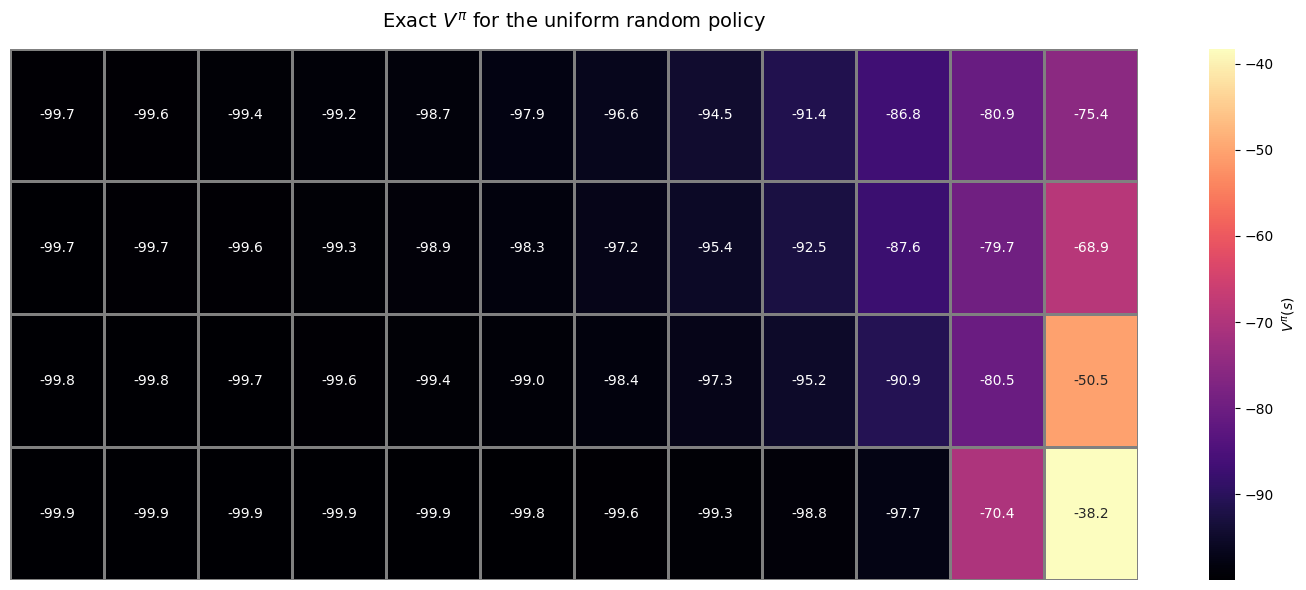

In [6]:
plot_gridworld_values(
    V_random[:nS].reshape(shape),
    title="Exact $V^\\pi$ for the uniform random policy",
    cbar_label="$V^\\pi(s)$",
)

---
# 🔁 Iterative Policy Evaluation

Solving the linear system directly costs $O(|\mathcal{S}|^3)$. That is fine for 49 states and hopeless for a million.

The alternative is to read the Bellman equation as an **assignment** rather than an equality, and apply it repeatedly:

$$V_{k+1} \leftarrow R^\pi + \gamma P^\pi V_k.$$

The operator on the right is a **$\gamma$-contraction** in the sup-norm: applying it to two different value functions brings them at least a factor $\gamma$ closer together,

$$\|T^\pi V - T^\pi U\|_\infty \le \gamma \|V - U\|_\infty.$$

By the Banach fixed-point theorem it therefore has a unique fixed point — which is exactly $V^\pi$ — and iterating from *any* starting point converges to it geometrically. Each sweep costs $O(|\mathcal{S}|^2)$ instead of $O(|\mathcal{S}|^3)$.

This is the algorithm that Temporal Difference learning in `RL01` imitates from samples: TD(0) replaces the exact expectation $P^\pi V$ with a single sampled successor.

**⭐ Exercise.** Implement `iterative_policy_evaluation`. Starting from $V_0 = 0$, apply the update above until $\|V_{k+1} - V_k\|_\infty <$ `tol`. Collect each $\|V_{k+1} - V_k\|_\infty$ into `deltas` so we can plot convergence.

In [7]:
def iterative_policy_evaluation(P, R, pi, gamma, tol=1e-10, max_iter=100_000):
    P_pi, R_pi = policy_matrices(P, R, pi)
    V = np.zeros(P.shape[0])
    deltas = []

    for k in range(max_iter):
        # Your code goes here: -------------------------------------
        V_new = R_pi + gamma * P_pi @ V
        delta = np.max(np.abs(V_new - V))
        deltas.append(delta)

        V = V_new

        if delta < tol:
            break
        # ----------------------------------------------------------

    return V, k + 1, deltas


V_iter, n_sweeps, deltas = iterative_policy_evaluation(P, R, pi_random, GAMMA)

err = np.max(np.abs(V_iter - V_random))
print(f"{n_sweeps} sweeps  |  max |V_iterative - V_exact| = {err:.2e}")

429 sweeps  |  max |V_iterative - V_exact| = 1.64e-09


The two agree to numerical precision — the same answer by two different routes.

The plot below shows the change per sweep decaying geometrically. The dashed line is the rate $\gamma^k$ predicted by the contraction argument.

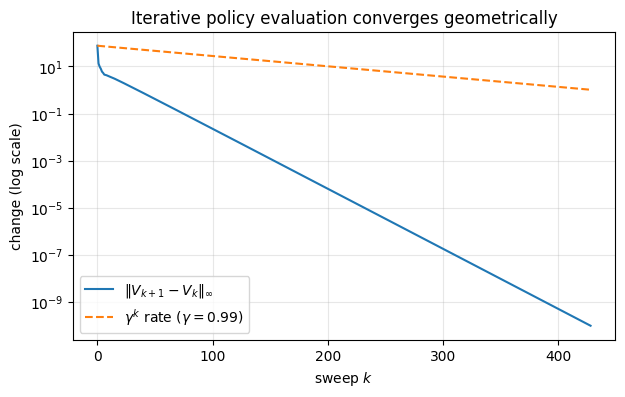

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(deltas, label=r"$\|V_{k+1} - V_k\|_\infty$")
ax.semilogy(deltas[0] * GAMMA ** np.arange(len(deltas)), "--",
            label=rf"$\gamma^k$ rate ($\gamma = {GAMMA}$)")
ax.set_xlabel("sweep $k$")
ax.set_ylabel("change (log scale)")
ax.set_title("Iterative policy evaluation converges geometrically")
ax.legend()
ax.grid(alpha=.3)
plt.show()

---
# 🧭 Policy Iteration

Evaluation tells us how good a policy is. To *improve* it we need action values:

$$Q^\pi(s, a) = R(s, a) + \gamma \sum_{s'} p(s' \mid s, a)\, V^\pi(s').$$

The **policy improvement theorem** states that acting greedily with respect to $Q^\pi$,

$$\pi'(s) = \arg\max_a Q^\pi(s, a),$$

yields a policy with $V^{\pi'} \ge V^\pi$ **in every state**, with strict improvement somewhere unless $\pi$ is already optimal.

**Policy iteration** alternates the two steps until the greedy policy stops changing:

$$\pi_0 \xrightarrow{\text{evaluate}} V^{\pi_0} \xrightarrow{\text{improve}} \pi_1 \xrightarrow{\text{evaluate}} V^{\pi_1} \xrightarrow{\text{improve}} \cdots$$

Since there are finitely many deterministic policies and each iteration strictly improves, this terminates at the optimum after finitely many steps — usually a startlingly small number.

**⭐ Exercise.** Implement the three pieces: `q_from_v` (the $Q$ formula above), `greedy_policy` (a deterministic policy as a one-hot matrix), and `policy_iteration` (alternate evaluation and improvement, stopping when the greedy action is unchanged in every state).

In [13]:
def q_from_v(P, R, V, gamma):
    """One-step lookahead: Q[s, a] from V."""
    # Your code goes here: -------------------------------------
    Q = R + gamma * np.einsum('sat,t->sa', P, V)
    return Q
    # ----------------------------------------------------------


def greedy_policy(Q):
    """Deterministic greedy policy, as a one-hot matrix."""
    # Your code goes here: -------------------------------------
    pi = np.zeros(Q.shape)
    best_actions = np.argmax(Q, axis=1)

    for s in range(nS):
        pi[s, best_actions[s]] = 1.0

    return pi
    # ----------------------------------------------------------


def policy_iteration(P, R, gamma, max_iter=1_000):
    pi = np.ones(R.shape) / R.shape[1]      # start from the random policy

    for k in range(max_iter):
        # Your code goes here: -------------------------------------
        V, _, _ = iterative_policy_evaluation(P, R, pi, gamma)

        Q = q_from_v(P, R, V, gamma)
        pi_new = greedy_policy(Q)

        if np.array_equal(pi_new, pi):
            pi = pi_new
            break

        pi = pi_new
        # ----------------------------------------------------------

    return V, pi, k + 1


V_star_pi, pi_star, n_iters = policy_iteration(P, R, GAMMA)
print(f"converged in {n_iters} iterations  |  V*(start) = {V_star_pi[START]:.2f}")

converged in 9 iterations  |  V*(start) = -12.25


Let's render the optimal policy as arrows. `C` marks the cliff and `G` the goal.

In [14]:
def show_policy(pi):
    arrows = np.array(list("^>v<"))[pi.argmax(1)[:nS]].reshape(shape).astype(object)
    arrows[3, 1:-1] = "C"
    arrows[3, -1] = "G"
    print("\n".join("  ".join(row) for row in arrows))


show_policy(pi_star)

>  >  >  >  >  >  >  >  >  >  >  v
>  >  >  >  >  >  >  >  >  >  >  v
>  >  >  >  >  >  >  >  >  >  >  v
^  C  C  C  C  C  C  C  C  C  C  G


The agent climbs away from the bottom row and only drops down in the last column. With $-100$ for a fall and $-1$ per step, the detour is cheap insurance.

Worth remembering for `RL02`: $Q$-learning recovers this same **optimal** policy, while SARSA — which evaluates the $\varepsilon$-greedy policy it actually follows, including its exploratory mistakes — prefers a safer route further from the edge.

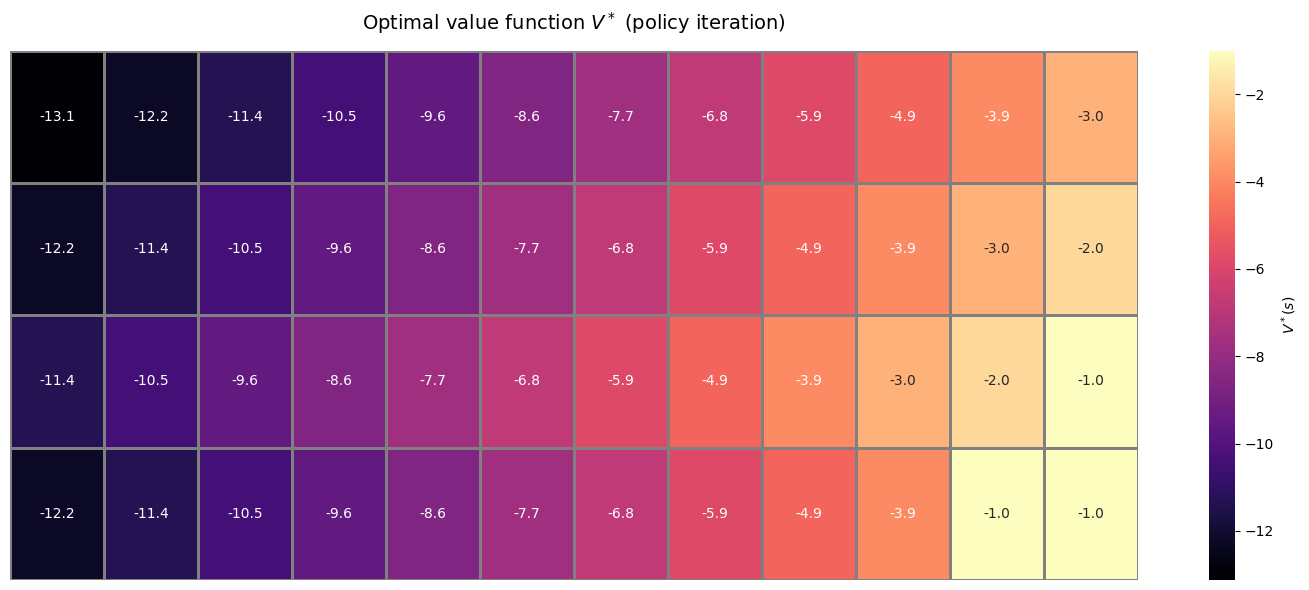

In [15]:
plot_gridworld_values(
    V_star_pi[:nS].reshape(shape),
    title="Optimal value function $V^*$ (policy iteration)",
    cbar_label="$V^*(s)$",
)

---
# ⚡ Value Iteration

Policy iteration solves a full linear system at every step — more precision than the improvement step actually needs, since only the $\arg\max$ matters. **Value iteration** collapses evaluation and improvement into a single update, the **Bellman optimality operator**:

$$V_{k+1}(s) \leftarrow \max_a \left[ R(s, a) + \gamma \sum_{s'} p(s' \mid s, a)\, V_k(s') \right].$$

Like $T^\pi$, this operator is a $\gamma$-contraction, so it converges to its unique fixed point $V^*$ from any initialisation. The optimal policy is read off with one final greedy step.

The trade-off against policy iteration: much cheaper iterations, but more of them.

**⭐ Exercise.** Implement `value_iteration` using `q_from_v`, iterating until $\|V_{k+1} - V_k\|_\infty <$ `tol`.

In [16]:
def value_iteration(P, R, gamma, tol=1e-10, max_iter=100_000):
    V = np.zeros(R.shape[0])
    deltas = []

    for k in range(max_iter):
        # Your code goes here: -------------------------------------
        Q = q_from_v(P, R, V, gamma)

        V_new = np.max(Q, axis=1)

        delta = np.max(np.abs(V_new - V))
        deltas.append(delta)

        V = V_new

        if delta < tol:
            break
        # ----------------------------------------------------------

    pi = greedy_policy(q_from_v(P, R, V, gamma))
    return V, pi, k + 1, deltas


V_star_vi, pi_vi, n_sweeps_vi, deltas_vi = value_iteration(P, R, GAMMA)

print(f"value iteration:  {n_sweeps_vi} sweeps")
print(f"policy iteration: {n_iters} iterations")
print(f"max |V_VI - V_PI|   = {np.max(np.abs(V_star_vi - V_star_pi)):.2e}")
print(f"same greedy policy: {np.array_equal(pi_vi.argmax(1), pi_star.argmax(1))}")

value iteration:  15 sweeps
policy iteration: 9 iterations
max |V_VI - V_PI|   = 0.00e+00
same greedy policy: True


Both algorithms land on the same $V^*$ and the same optimal policy, as the theory promises. Policy iteration needs far fewer iterations, but each one is much more expensive.

### The effect of the discount factor

$\gamma$ controls both how far ahead the agent plans and how fast the contraction converges. A small $\gamma$ converges quickly but produces a myopic agent; a $\gamma$ close to $1$ plans further at the cost of many more sweeps.

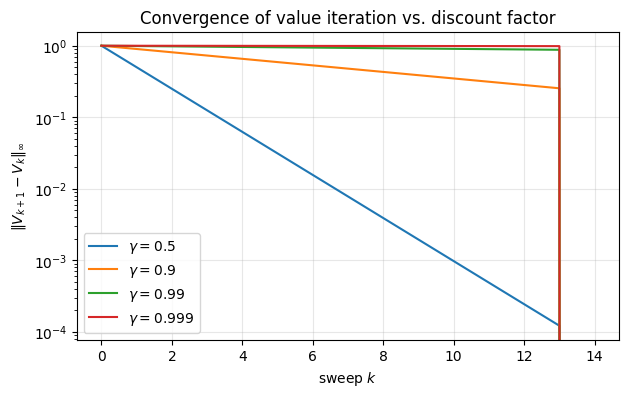

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))

for g in [0.5, 0.9, 0.99, 0.999]:
    _, _, _, d = value_iteration(P, R, g, tol=1e-12)
    ax.semilogy(d, label=rf"$\gamma = {g}$")

ax.set_xlabel("sweep $k$")
ax.set_ylabel(r"$\|V_{k+1} - V_k\|_\infty$")
ax.set_title("Convergence of value iteration vs. discount factor")
ax.legend()
ax.grid(alpha=.3)
plt.show()

---
# 🌉 What If We Don't Know the Model?

Everything above depended on one thing: having $p(s' \mid s, a)$ and $r(s, a)$ available as arrays. Given the model, finding the optimal policy is a linear-algebra problem.

That assumption is usually false. A robot does not come with its transition kernel; neither does a market, a game, or a physical system. And even when the dynamics *exist*, the state space is often far too large to enumerate — the $49 \times 4 \times 49$ table we built here would be astronomically large for chess or for continuous control.

Reinforcement learning is what remains when you delete $P$ and $R$ from this notebook and keep only the ability to **sample**: to be in a state, take an action, and observe what happens.

Each method in `RL02` is a sampled version of something computed exactly here:

| Dynamic programming (this notebook) | Reinforcement learning (`RL02`) |
| --- | --- |
| Exact solve $(I - \gamma P^\pi)^{-1} R^\pi$ | Every-Visit Monte Carlo |
| Iterative policy evaluation $V \leftarrow R^\pi + \gamma P^\pi V$ | TD(0) |
| Policy iteration | SARSA (on-policy control) |
| Value iteration | $Q$-learning (off-policy control) |

Keep `V_random` and `V_star_vi` in mind as ground truth: in `RL02` you can plot the Monte Carlo and TD estimates against them and watch the sampling error shrink.

**Onwards to `RL02_Prediction_and_Control`!**

---

### Source

Companion notebook for the **Reinforcement Learning Summer School 2026 (RLSS26)** materials, Milan, Italy — *RL Basics I: Introduction to Reinforcement Learning*.

Original authors (Politecnico di Milano): [Enea Gusmeroli](mailto:enea.gusmeroli@polimi.it) **•** [Cristiano Migali](mailto:cristiano.migali@polimi.it) **•** [Davide Salaorni](mailto:davide.salaorni@polimi.it) **•** [Gianmarco Tedeschi](mailto:gianmarco.tedeschi@polimi.it)

Original materials: [github.com/gianmtedeschi/tutorial-rlss26](https://github.com/gianmtedeschi/tutorial-rlss26)